In [2]:
import numpy as np
import pandas as pd
import timecorr as tc
import hypertools as hyp
import supereeg as se
from matplotlib import pyplot as plt
import seaborn as sns
import os
from glob import glob as lsdir
from scipy.io import loadmat as load
import numba
import nltools as nl
import nibabel as nib
from nilearn.input_data import NiftiMasker
from scipy.spatial.distance import pdist, cdist, squareform
from collections import deque

%matplotlib inline

In [3]:
datadir = os.path.join(os.getenv('HOME'), 'data', 'fMRI', 'dffr')
nii_files = lsdir(os.path.join(datadir, '*.nii'))
regressor_files = lsdir(os.path.join(datadir, 'regmats', '*.mat'))

In [4]:
def cluster_maxdist(dists, maxdist):
    '''
    returns cluster labels for observations such that each observation
    in a group is within maxdist units of at least one other observation
    in the same group
    '''
    
    assert np.all(dists >= 0), 'All distances must be non-negative'
    assert maxdist > 0, 'Maximum distance must be positive'
    
    labels = np.zeros(dists.shape[0])
    
    group = 1
    i = 0
    while i < dists.shape[0]:
        #if i is in a group already, continue
        if labels[i] != 0:
            i += 1
            continue
        
        #go through all existing groups and check if i
        #is within maxdist units of any element of an existing group
        for g in (np.arange(group) + 1):
            next_inds = labels == g
            next_dists = dists[next_inds, i]
            if np.any(next_dists <= maxdist):
                labels[i] = g
                break
        
        #if i matched a prior group, continue
        if labels[i] != 0:
            continue
        
        #if we get here, i is not within maxdist units of any prior
        #group.  so we need a new group.  assign i, and any elements
        #within maxdist units of i, to the new group
        labels[i] = group
        
        next_dists = dists[i, :]
        labels[next_dists <= maxdist] = group
        
        #print(f'{np.sum(next_dists <= maxdist)} new observations assigned')
        
        #find the next unassigned observation and increment the group number
        if not np.any(labels == 0):
            break
        else:
            i = np.min(np.nonzero(labels))
            group += 1
    return labels - 1

In [21]:
def get_neurosynth_mask(maxdist=6):
    mask_fname = 'Neurosynth Parcellation_0.nii.gz'
    if not os.path.exists(mask_fname):
        print('Downloading mask...')
        !wget http://neurovault.org/media/images/2099/Neurosynth%20Parcellation_0.nii.gz
    print('Loading mask...')
    nii = nib.load(mask_fname)
    
    print('Converting Nifti file to Brain object...')
    bo = se.Brain(nii, filter=None)
    
    print('Extracting data from Brain object...')
    labels = bo.data
    
    
    clusters = np.unique(labels)
    clusters = clusters[clusters > 0]
    next_free_label = np.round(np.max(clusters) + 1)
    
    for i in clusters:
        print(f'Parsing cluster {int(i)} of {len(clusters)-1}')
        #print(f'next free label: {next_free_label}')
        next_inds = np.where(np.isclose(labels, i))[1]
        
        #print(f'Sanity check 1 passed: {np.all(np.isclose(labels.T.iloc[next_inds], i))}')
        
        #print(f'number of observations in cluster {np.round(i)}: {len(next_inds)}')
        next_locs = bo.get_locs().iloc[next_inds]
        
        next_sub_clusters = cluster_maxdist(squareform(pdist(next_locs)), maxdist)
        #print(f'{len(np.unique(next_sub_clusters))} sub-cluster(s) found')
        next_sub_clusters[next_sub_clusters > 0] = next_sub_clusters[next_sub_clusters > 0] + next_free_label - 1
        next_sub_clusters[next_sub_clusters == 0] = np.round(i)
        
        #print(f'next sub-clusters: {np.unique(next_sub_clusters)} (shape: {next_sub_clusters.shape})')
        
        labels.T.iloc[next_inds] = np.round(next_sub_clusters)[:, np.newaxis]
        #print(f'Sanity check 2 passed: {np.all(labels.T.iloc[next_inds] in np.unique(np.round(next_sub_clusters)))}')
                
        next_free_label = np.round(np.max(labels.values) + 1)
    
    bo.data = labels.astype(np.int16)
    return bo

In [22]:
labels = get_neurosynth_mask(maxdist=10)

Loading mask...
Converting Nifti file to Brain object...
Extracting data from Brain object...
Parsing cluster 1 of 49
Parsing cluster 2 of 49
Parsing cluster 3 of 49
Parsing cluster 4 of 49
Parsing cluster 5 of 49
Parsing cluster 6 of 49
Parsing cluster 6 of 49
Parsing cluster 7 of 49
Parsing cluster 8 of 49
Parsing cluster 9 of 49
Parsing cluster 10 of 49
Parsing cluster 11 of 49
Parsing cluster 13 of 49
Parsing cluster 14 of 49
Parsing cluster 15 of 49
Parsing cluster 16 of 49
Parsing cluster 17 of 49
Parsing cluster 18 of 49
Parsing cluster 18 of 49
Parsing cluster 19 of 49
Parsing cluster 20 of 49
Parsing cluster 21 of 49
Parsing cluster 22 of 49
Parsing cluster 23 of 49
Parsing cluster 25 of 49
Parsing cluster 26 of 49
Parsing cluster 27 of 49
Parsing cluster 28 of 49
Parsing cluster 29 of 49
Parsing cluster 30 of 49
Parsing cluster 31 of 49
Parsing cluster 31 of 49
Parsing cluster 32 of 49
Parsing cluster 33 of 49
Parsing cluster 34 of 49
Parsing cluster 35 of 49
Parsing cluster 

In [ ]:
slice_figdir = 'clusters'
if not os.path.exists(slice_figdir):
    os.makedirs(slice_figdir)


In [ ]:
np.unique(labels.

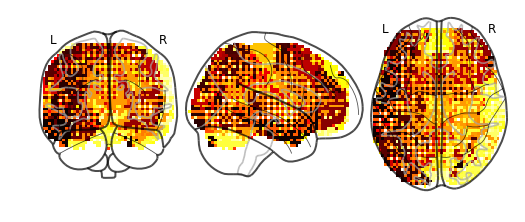

In [9]:
labels.plot_data()

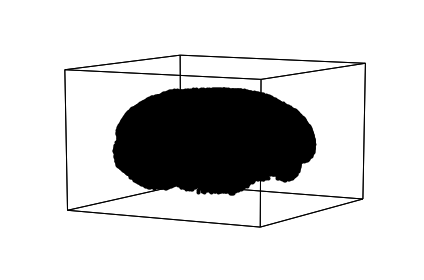

In [10]:
labels.plot_locs()

In [16]:
r0 = load(regressor_files[0])

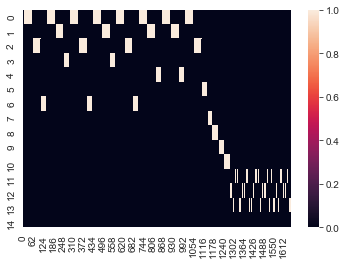

In [19]:
sns.heatmap(r0['all_regressors'])

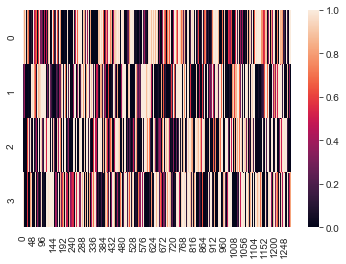

In [21]:
sns.heatmap(r0['results'])

In [25]:
# credit: https://stackoverflow.com/questions/47004506/check-if-a-numpy-array-is-sorted
@numba.jit
def is_sorted(a):
    for i in range(a.size-1):
         if a[i+1] < a[i] :
               return False
    return True

In [31]:
def ribbon(x, y, lb, ub=None, color='k', alpha='0.5'):
    #assert is_sorted(x), 'x-coordinates must be monotonically increasing'
    
    if ub is None:
        ub = lb
    h1 = plt.fill_between(x, y-lb, y+ub, color=color, alpha=alpha)
    h2 = plt.plot(x, y, color=color)
    return h1, h2

Source: https://neurolearn.readthedocs.io/en/latest/auto_examples/01_DataOperations/plot_mask.html#sphx-glr-auto-examples-01-dataoperations-plot-mask-py
```
from nltools.mask import expand_mask, collapse_mask
from nltools.data import Brain_Data
from nltools.datasets import fetch_pain

data = fetch_pain()

mask = Brain_Data('http://neurovault.org/media/images/2099/Neurosynth%20Parcellation_0.nii.gz')
mask.plot()

masked_data = data.apply_mask(mask)
masked_data.mean().plot()
```

In [115]:
def get_neurosynth_mask():
    mask = nl.Brain_Data('http://neurovault.org/media/images/2099/Neurosynth%20Parcellation_0.nii.gz')
    return mask.to_nifti()

In [116]:
nii_mask = get_neurosynth_mask()

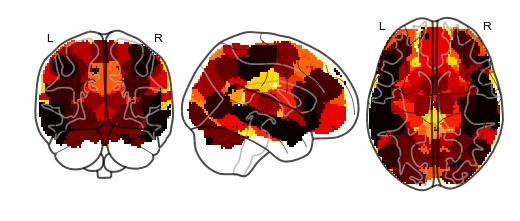

In [117]:
nl.plotting.plot_glass_brain(nii_mask)

In [81]:
np.unique(nii_mask.get_data())

array([ 0.        ,  1.        ,  2.        ,  3.        ,  4.        ,
        5.        ,  6.00000001,  6.99999999,  8.        ,  9.        ,
       10.        , 11.        , 12.        , 13.        , 14.        ,
       15.        , 16.        , 17.        , 18.00000001, 18.99999999,
       20.        , 21.        , 22.        , 23.        , 24.        ,
       25.        , 26.        , 27.        , 28.        , 29.        ,
       30.        , 31.00000001, 31.99999999, 33.        , 34.        ,
       35.        , 36.        , 37.        , 38.        , 39.        ,
       40.        , 41.        , 42.        , 43.00000001, 43.99999999,
       45.        , 46.        , 47.        , 48.        , 49.        ,
       49.99999999])

In [49]:
xNii = xBrain.to_nii()

In [50]:
nl_xBrain = nl.Brain_Data(xNii)

In [67]:
nl_xBrain2 = nl.Brain_Data(nii_files[0])

In [52]:
x_masked = nl_xBrain.extract_roi(mask)

In [ ]:
x_masked2 = nl_xBrain2.extract_roi(mask)

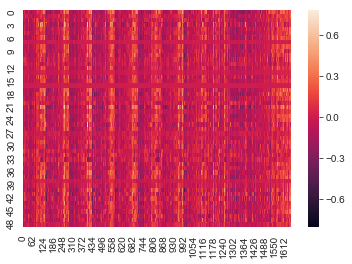

In [55]:
sns.heatmap(x_masked)

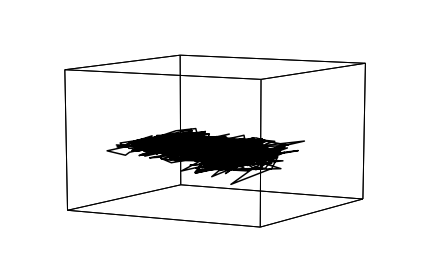

In [66]:
hyp.plot(x_masked.T, 'k-')

TypeError: '<' not supported between instances of 'str' and 'int'

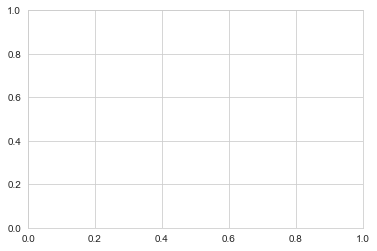

In [32]:
ribbon(np.arange(10), np.random.rand(10), np.random.randn(10))